In [351]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import Ridge
from sklearn.cluster import KMeans
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor
from sklearn.linear_model import Lasso, Ridge
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report

In [352]:
air_data = pd.read_csv("AirQualityUCI.csv")
air_data.head(20)

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,3/10/2004,18:00:00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,NaN,NaN
1,3/10/2004,19:00:00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,NaN,NaN
2,3/10/2004,20:00:00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,NaN,NaN
3,3/10/2004,21:00:00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,NaN,NaN
4,3/10/2004,22:00:00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,NaN,NaN
5,3/10/2004,23:00:00,1.2,1197.0,38.0,4.7,750.0,89.0,1337.0,96.0,1393.0,949.0,11.2,59.2,0.7848,NaN,NaN
6,3/11/2004,0:00:00,1.2,1185.0,31.0,3.6,690.0,62.0,1462.0,77.0,1333.0,733.0,11.3,56.8,0.7603,NaN,NaN
7,3/11/2004,1:00:00,1.0,1136.0,31.0,3.3,672.0,62.0,1453.0,76.0,1333.0,730.0,10.7,60.0,0.7702,NaN,NaN
8,3/11/2004,2:00:00,0.9,1094.0,24.0,2.3,609.0,45.0,1579.0,60.0,1276.0,620.0,10.7,59.7,0.7648,NaN,NaN
9,3/11/2004,3:00:00,0.6,1010.0,19.0,1.7,561.0,-200.0,1705.0,-200.0,1235.0,501.0,10.3,60.2,0.7517,NaN,NaN


In [353]:
print(air_data.info())
print(air_data.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9471 entries, 0 to 9470
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   object 
 1   Time           9357 non-null   object 
 2   CO(GT)         9357 non-null   float64
 3   PT08.S1(CO)    9357 non-null   float64
 4   NMHC(GT)       9357 non-null   float64
 5   C6H6(GT)       9357 non-null   float64
 6   PT08.S2(NMHC)  9357 non-null   float64
 7   NOx(GT)        9357 non-null   float64
 8   PT08.S3(NOx)   9357 non-null   float64
 9   NO2(GT)        9357 non-null   float64
 10  PT08.S4(NO2)   9357 non-null   float64
 11  PT08.S5(O3)    9357 non-null   float64
 12  T              9357 non-null   float64
 13  RH             9357 non-null   float64
 14  AH             9357 non-null   float64
 15  Unnamed: 15    0 non-null      float64
 16  Unnamed: 16    0 non-null      float64
dtypes: float64(15), object(2)
memory usage: 1.2+ MB
None

In [354]:
air_data.drop(columns=['Unnamed: 15', 'Unnamed: 16'], inplace=True)

In [355]:
air_data['Datetime'] = pd.to_datetime(air_data['Date'] + ' ' + air_data['Time'], errors='coerce')

air_data['DayOfWeek'] = air_data['Datetime'].dt.dayofweek
air_data['Hour'] = air_data['Datetime'].dt.hour
air_data['Month'] = air_data['Datetime'].dt.month

air_data.drop(columns=['Datetime', 'Date', 'Time'], inplace=True)

In [356]:
imputer = KNNImputer(n_neighbors=10)
air_data_imputed = pd.DataFrame(imputer.fit_transform(air_data), columns=air_data.columns)

In [357]:
def remove_outliers_zscore(data, column, threshold=2):
    z_scores = (data[column] - data[column].mean()) / data[column].std()
    return data[z_scores.abs() <= threshold]
# apply function to all numeric columns (float64, int64)
for column in air_data_imputed.select_dtypes(include=['float64', 'int64']).columns:
    air_data_imputed = remove_outliers_zscore(air_data_imputed, column)

air_data_imputed = pd.get_dummies(air_data_imputed, columns=['DayOfWeek', 'Hour', 'Month'], 
                                                    drop_first=True)

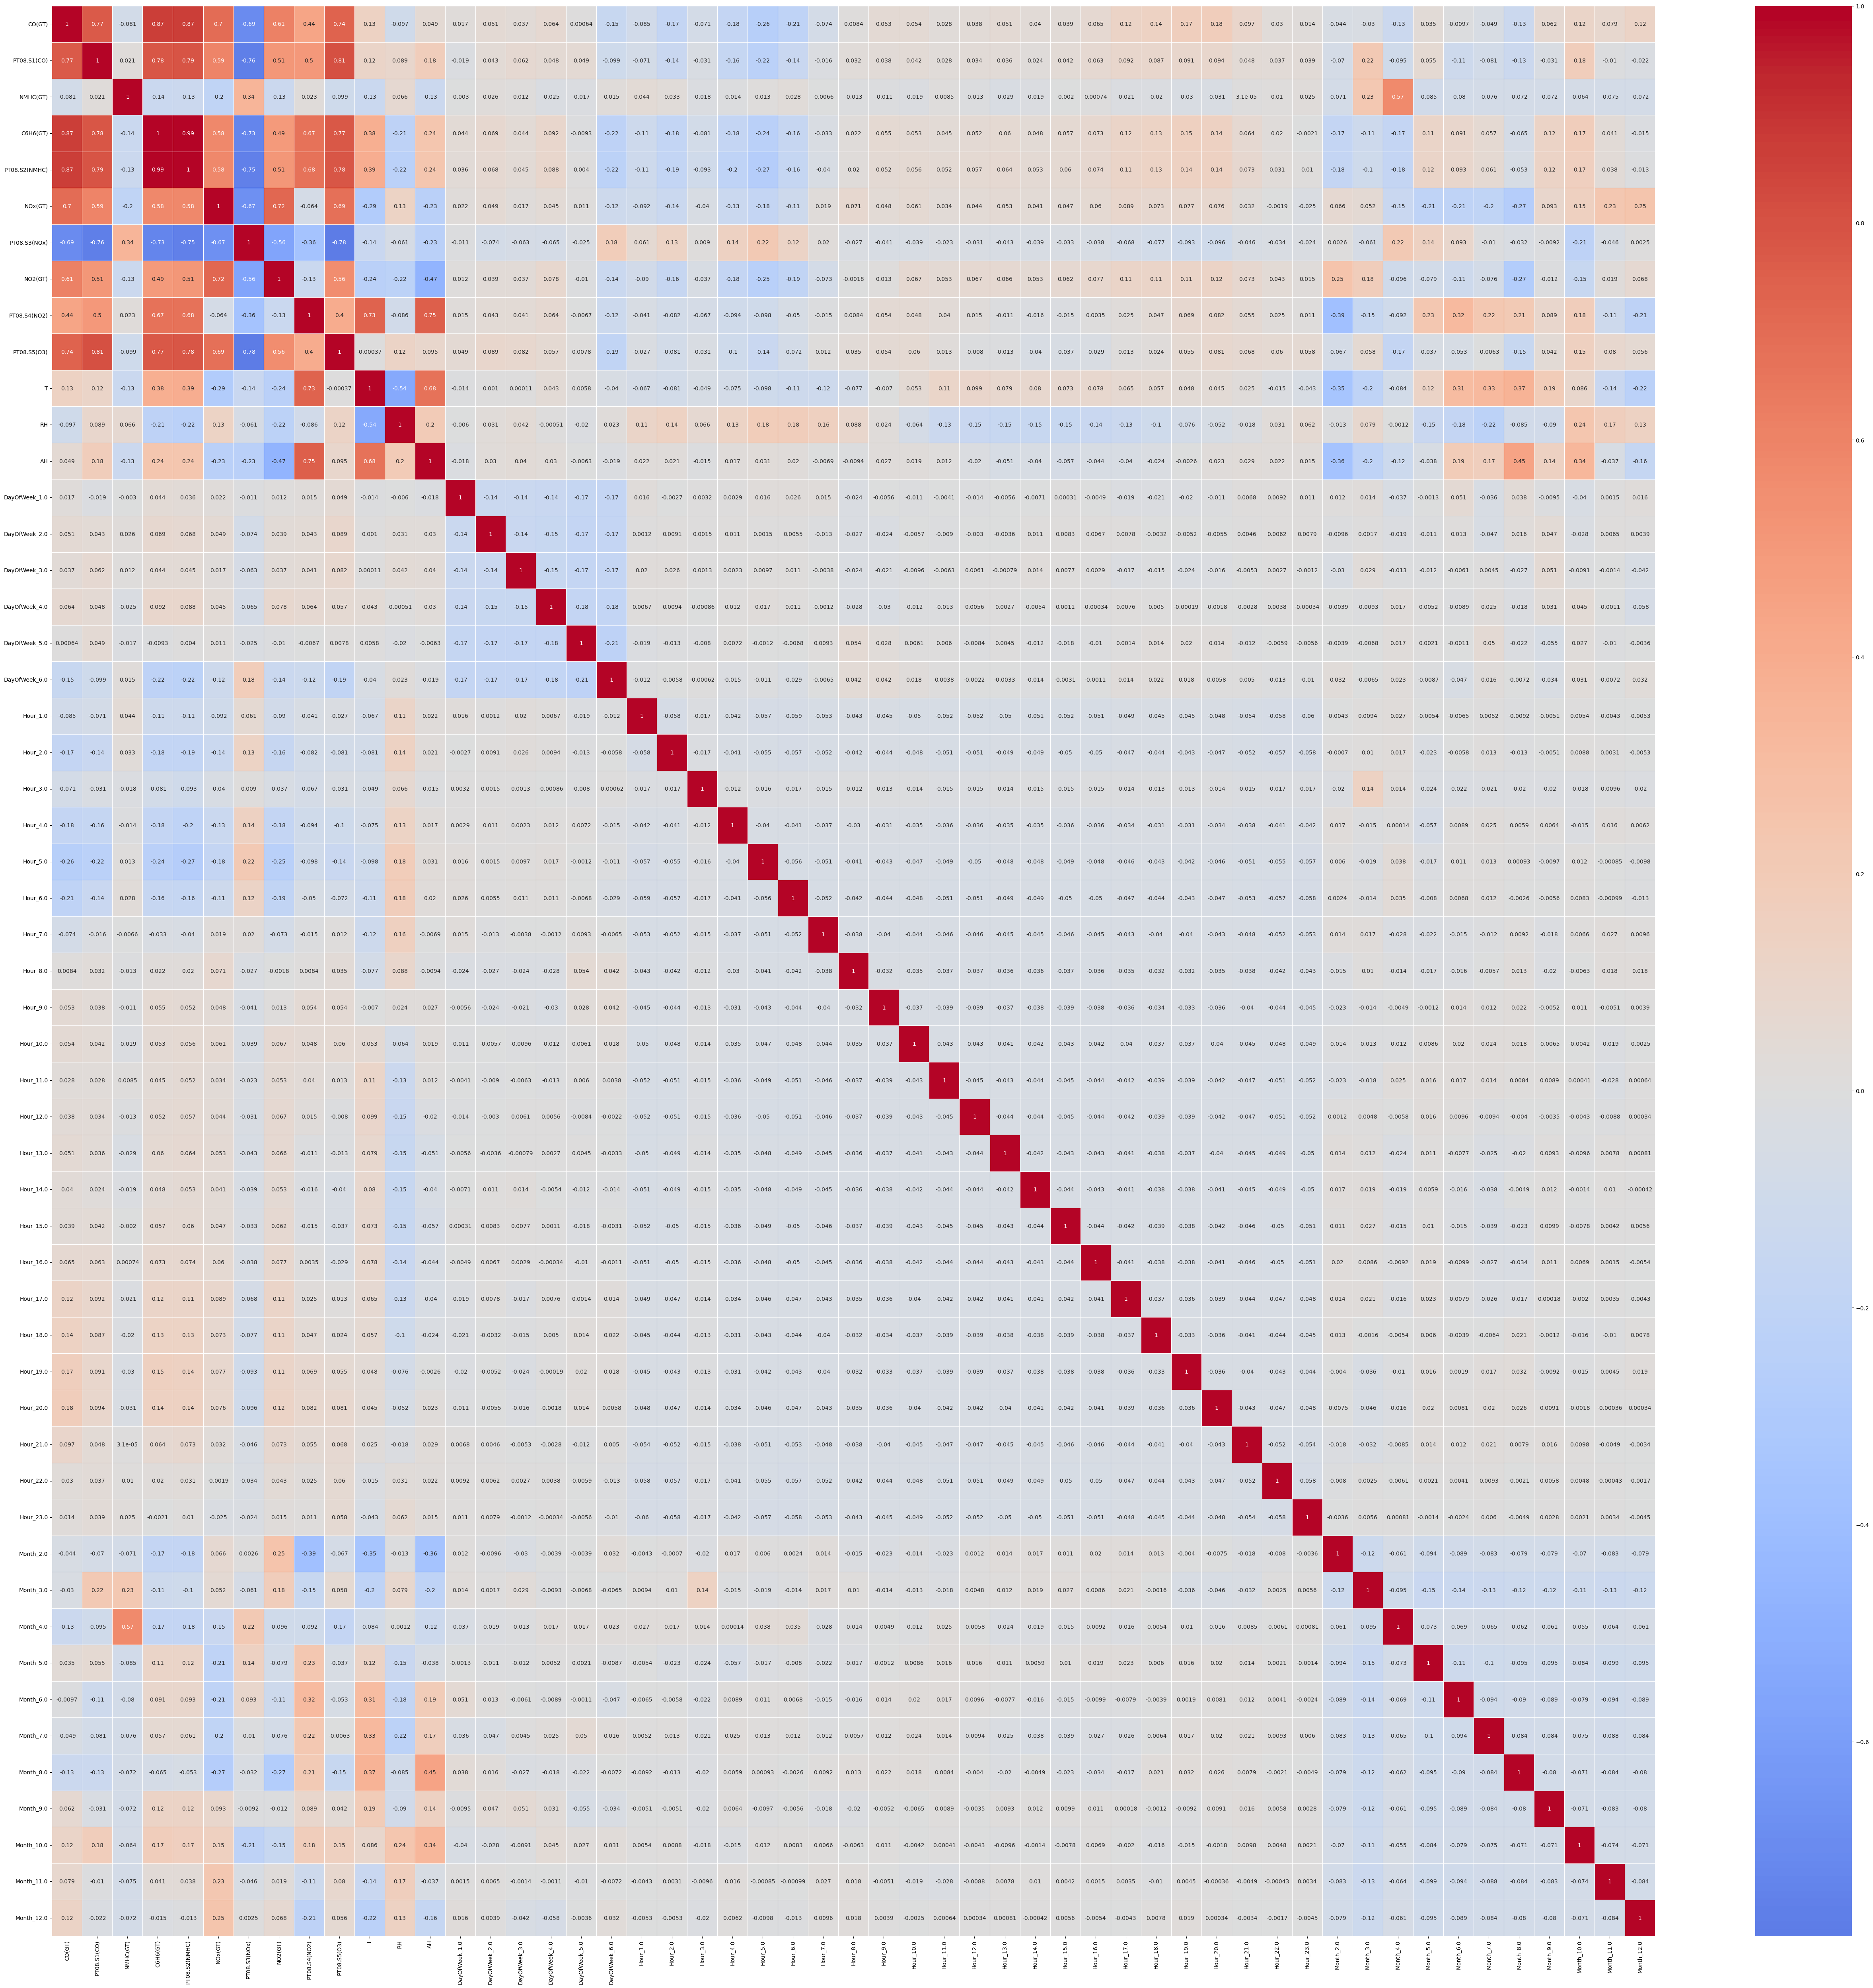

In [358]:
corr_matrix = air_data_imputed.corr()
plt.figure(figsize=(65, 63))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, linewidths=0.5)

plt.title('')
plt.show()

# Task 2.1 (Regression models comparison [CO(GT] to be predicted)
* 

Metrics for the Lasso regression:
R²: 0.8502
MSE: 0.1093
RMSE: 0.3306
MAE: 0.2206

Metrics for the XGBoost:
R²: 0.8761
MSE: 0.0905
RMSE: 0.3007
MAE: 0.2006

Metrics for the Random Forest:
R²: 0.8286
MSE: 0.1251
RMSE: 0.3537
MAE: 0.2425

Metrics for the Ridge regression:
R²: 0.8594
MSE: 0.1026
RMSE: 0.3203
MAE: 0.2150



/var/folders/11/wnz304n132d_2czfmkhjmbch0000gn/T/ipykernel_56365/4244524771.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(r2_scores.keys()), y=list(r2_scores.values()), palette='coolwarm')


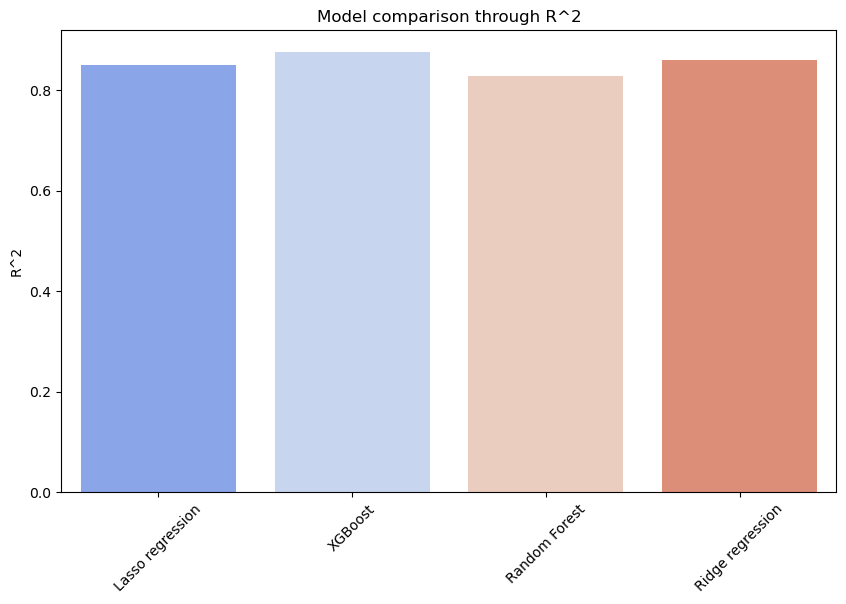

In [359]:
X_imputed = air_data_imputed.drop(columns=['CO(GT)'])
y_imputed = air_data_imputed['CO(GT)']

# Norm
scaler = StandardScaler()
X_imputed_scaled = scaler.fit_transform(X_imputed)

X_train, X_test, y_train, y_test = train_test_split(X_imputed_scaled, y_imputed, 
                                                    test_size=0.2, random_state=42)

models =  { "Lasso regression": Lasso(alpha=0.01),
            "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5),
            "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42),
            "Ridge regression": Ridge(alpha=1.0)}


def print_metrics(y_true, y_pred, model_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f"Metrics for the {model_name}:")
    print(f"R²: {r2:.4f}")
    print(f"MSE: {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}\n")
    return r2, mse, rmse, mae

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    metrics = print_metrics(y_test, y_pred, name)
    results[name] = metrics

r2_scores = {k: v[0] for k, v in results.items()}
plt.figure(figsize=(10, 6))
sns.barplot(x=list(r2_scores.keys()), y=list(r2_scores.values()), palette='coolwarm')
plt.title('Model comparison through R^2')
plt.ylabel('R^2')
plt.xticks(rotation=45)
plt.show()


# Task 2.2 (Classification models comparison [High_NOx] to be predicted)
* The classification model predicts whether the NOx(GT) level exceeds 200, indicating a high level of air pollution assuming all values  > 200 as 1 (since mean is 191), and other values as 0. 

191.17020819918437
Model performance for LogisticRegression:
Accuracy: 0.9335
Precision: 0.9231
Recall: 0.9396
Confusion matrix:
[[450  35]
 [ 27 420]]




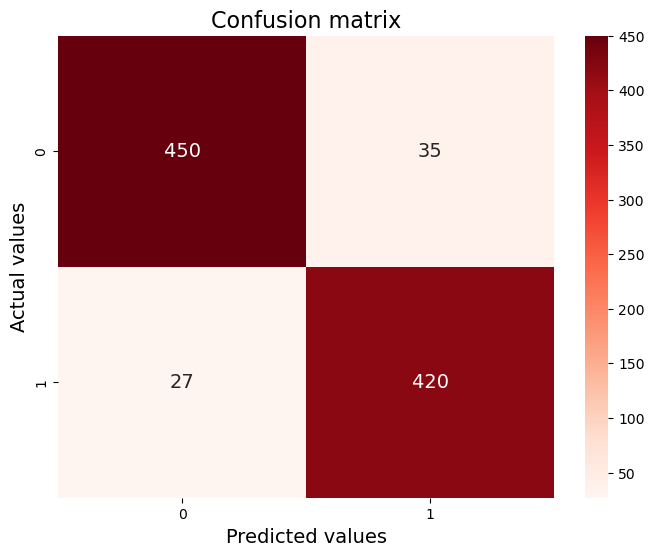

Model performance for RandomForestClassifier:
Accuracy: 0.9067
Precision: 0.8846
Recall: 0.9262
Confusion matrix:
[[431  54]
 [ 33 414]]




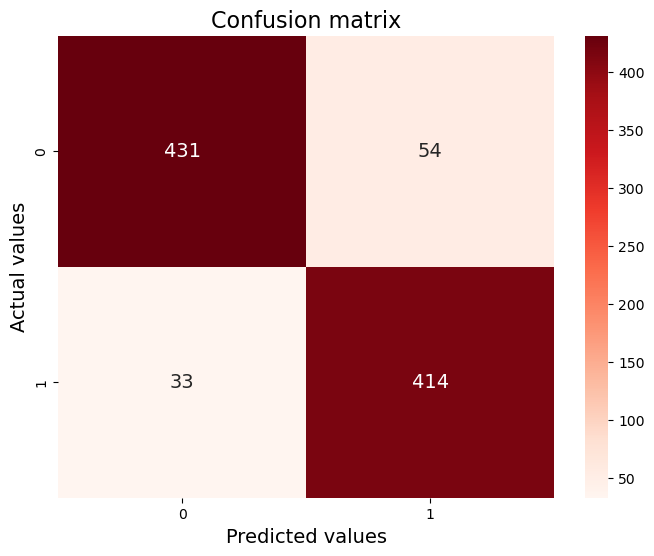

/var/folders/11/wnz304n132d_2czfmkhjmbch0000gn/T/ipykernel_56365/2814108983.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(accuracy_scores.keys()), y=list(accuracy_scores.values()), palette='viridis')


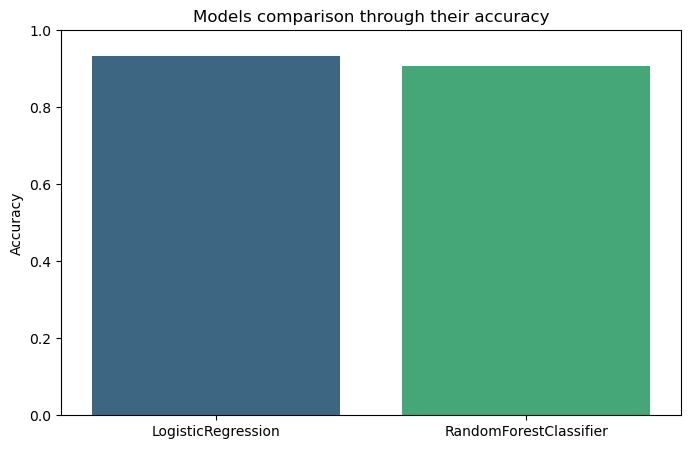

In [360]:
print(air_data_imputed['NOx(GT)'].mean())
threshold = air_data_imputed['NOx(GT)'].median()
air_data_imputed['High_NOx'] = (air_data_imputed['NOx(GT)'] > threshold).astype(int)

X = air_data_imputed.drop(columns=['High_NOx', 'NOx(GT)', 'CO(GT)'])
y = air_data_imputed['High_NOx']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

models = {"LogisticRegression": LogisticRegression(),
          "RandomForestClassifier": RandomForestClassifier(n_estimators=100,max_depth=5, 
                                                           random_state=42)}

def evaluate_model(y_true, y_pred, model_name):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)

    print(f"Model performance for {model_name}:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print("Confusion matrix:")
    print(cm)
    print("\n")
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', annot_kws={"size": 14})
    plt.title('Confusion matrix', fontsize=16)  
    plt.xlabel('Predicted values', fontsize=14)
    plt.ylabel('Actual values', fontsize=14) 
    plt.show()
    
    return accuracy, precision, recall, cm

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    metrics = evaluate_model(y_test, y_pred, name)
    results[name] = metrics

accuracy_scores = {k: v[0] for k, v in results.items()}
plt.figure(figsize=(8, 5))
sns.barplot(x=list(accuracy_scores.keys()), y=list(accuracy_scores.values()), palette='viridis')
plt.title('Models comparison through their accuracy')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.show()


# Task 2.3 (Clustering model)

[3.4555313146562225]
[3.4555313146562225, 3.5113630846171113]
[3.4555313146562225, 3.5113630846171113, 3.6260487333437985]
[3.4555313146562225, 3.5113630846171113, 3.6260487333437985, 3.5306400297393004]
[3.4555313146562225, 3.5113630846171113, 3.6260487333437985, 3.5306400297393004, 3.4250557085131255]
[3.4555313146562225, 3.5113630846171113, 3.6260487333437985, 3.5306400297393004, 3.4250557085131255, 3.283287424081144]
[3.4555313146562225, 3.5113630846171113, 3.6260487333437985, 3.5306400297393004, 3.4250557085131255, 3.283287424081144, 2.9548410332074977]
[3.4555313146562225, 3.5113630846171113, 3.6260487333437985, 3.5306400297393004, 3.4250557085131255, 3.283287424081144, 2.9548410332074977, 2.8727559122074933]


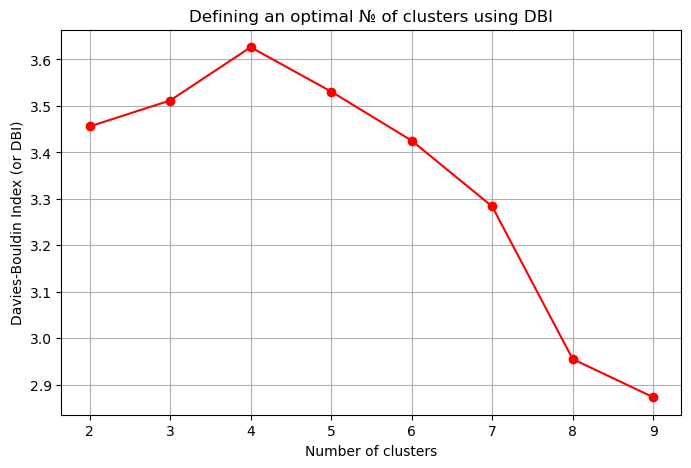

In [361]:
db_indices = []
clusters_range = range(2, 10)
for cluster in clusters_range:
    kmeans = KMeans(n_clusters=cluster, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    db_index = davies_bouldin_score(X_scaled, labels)
    db_indices.append(db_index)
    print(db_indices)
plt.figure(figsize=(8, 5))
plt.plot(clusters_range, db_indices, marker='o', linestyle='-', color='red')
plt.title('Defining an optimal № of clusters using DBI')
plt.xlabel('Number of clusters')
plt.ylabel('Davies-Bouldin Index (or DBI)')
plt.grid(True)
plt.show()


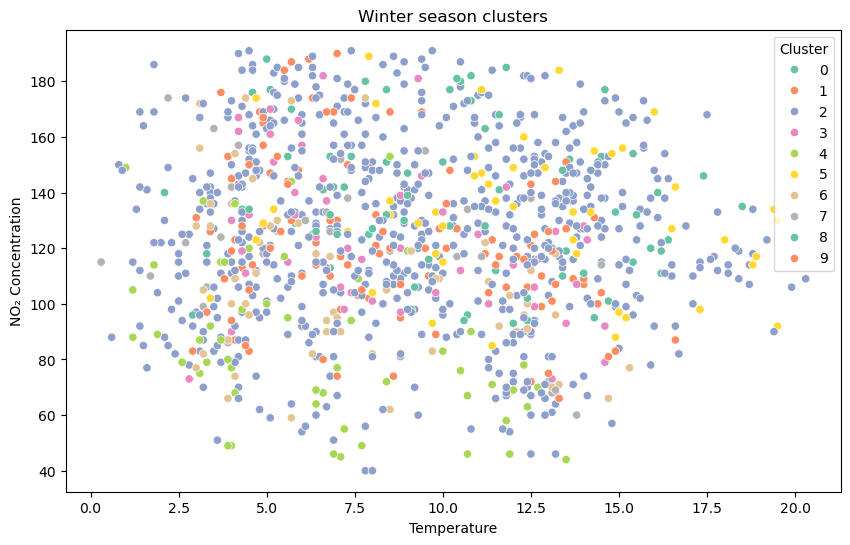

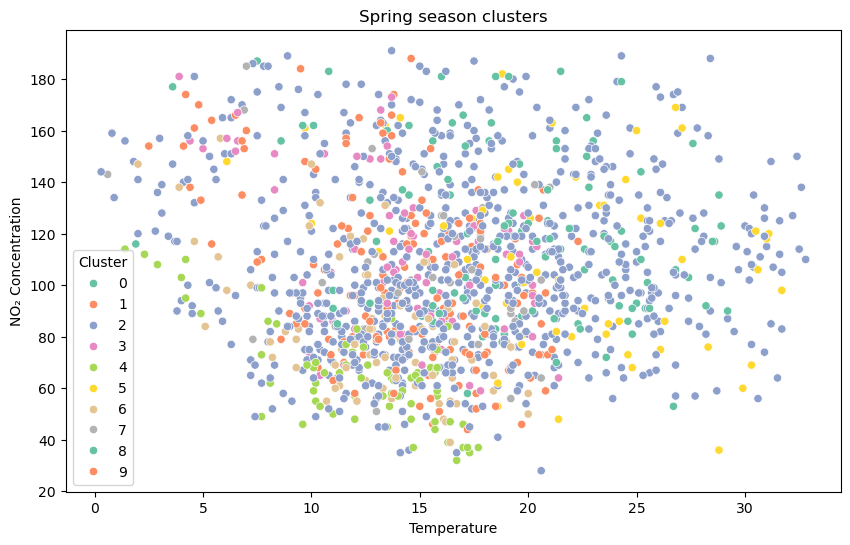

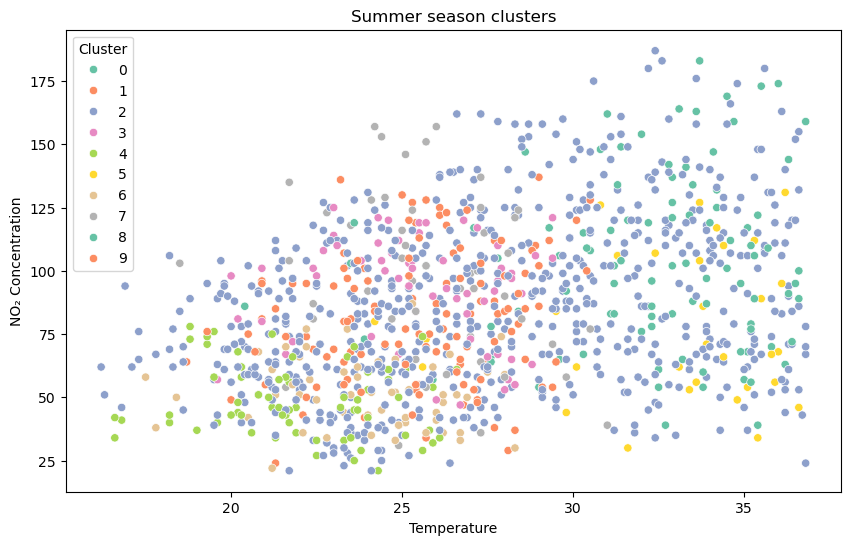

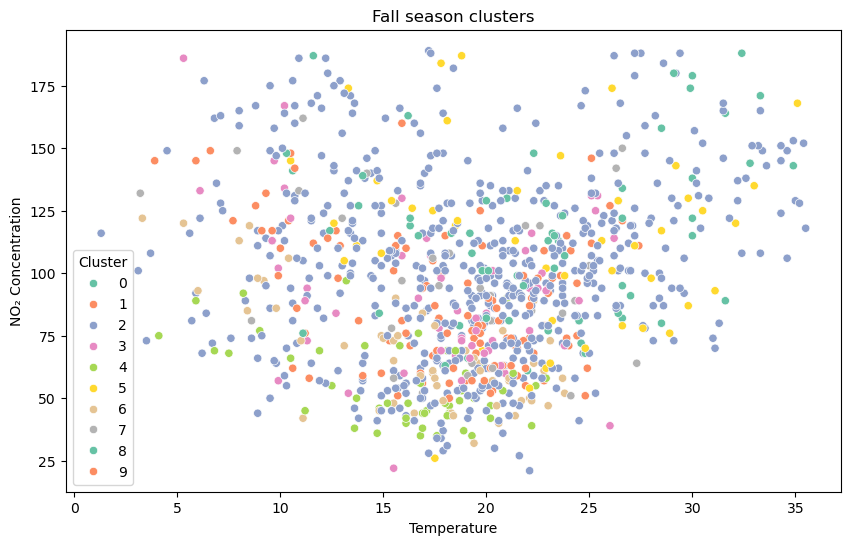

In [362]:

data['Month'] = data[month_columns].idxmax(axis=1).str.extract(r'Month_(\d+\.\d+)')[0].astype(float)
def assign_season(month):
    if month in [12, 1, 2]:
        return 'Winter'   
    elif month in [3, 4, 5]:
        return 'Spring'   
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

data['Season'] = data['Month'].apply(assign_season)

features = ['NO2(GT)', 'CO(GT)', 'T', 'RH', 'DayOfWeek_1.0', 'DayOfWeek_2.0', 'DayOfWeek_3.0', 
            'DayOfWeek_4.0', 'DayOfWeek_5.0', 'DayOfWeek_6.0', 'Hour_1.0', 'Hour_2.0', 'Hour_3.0', 
            'Hour_4.0', 'Hour_5.0', 'Hour_6.0', 'Hour_7.0', 'Hour_8.0', 'Hour_9.0', 'Hour_10.0', 
            'Hour_11.0', 'Hour_12.0', 'Hour_13.0', 'Hour_14.0', 'Hour_15.0', 'Hour_16.0', 
            'Hour_17.0', 'Hour_18.0', 'Hour_19.0', 'Hour_20.0', 'Hour_21.0', 'Hour_22.0', 'Hour_23.0']
scaler = StandardScaler()
scaled_features = scaler.fit_transform(data[features])

# tried 3, 4, 5, 7, 8, 9 but 10 is optimal, DBI score decreases rapidly after the point of seven
kmeans = KMeans(n_clusters=10, random_state=42)
data['Cluster'] = kmeans.fit_predict(scaled_features)

for season in ['Winter', 'Spring', 'Summer', 'Fall']:
    season_data = data[data['Season'] == season]
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=season_data['T'], y=season_data['NO2(GT)'], 
                    hue=season_data['Cluster'], palette='Set2')
    
    plt.title(f'{season} season clusters')
    plt.xlabel('Temperature')
    plt.ylabel('NO₂ Concentration')
    plt.legend(title='Cluster')
    plt.show()

cluster_summary = data.groupby(['Season', 'Cluster']).agg({'NO2(GT)': 'mean', 'T': 'mean', 'RH': 'mean'}).reset_index()


# Task 3_Classification model
Today, air pollution is one of the most dangerous problems for people and the planet. We decided that the goal of our project will be to create a machine learning model that will predict the level of air pollution. Our data will help the government to warn citizens in advance of impending worsening environmental conditions, which will help to preserve their health, and to apply measures in time to address these problems.

Mean of N02: 102.26271732131359
              precision    recall  f1-score   support

           0       0.92      0.95      0.94       548
           1       0.92      0.89      0.91       384

    accuracy                           0.92       932
   macro avg       0.92      0.92      0.92       932
weighted avg       0.92      0.92      0.92       932

[[520  28]
 [ 43 341]]
Size of train data: (3727, 6)
Size of test data: (932, 6)


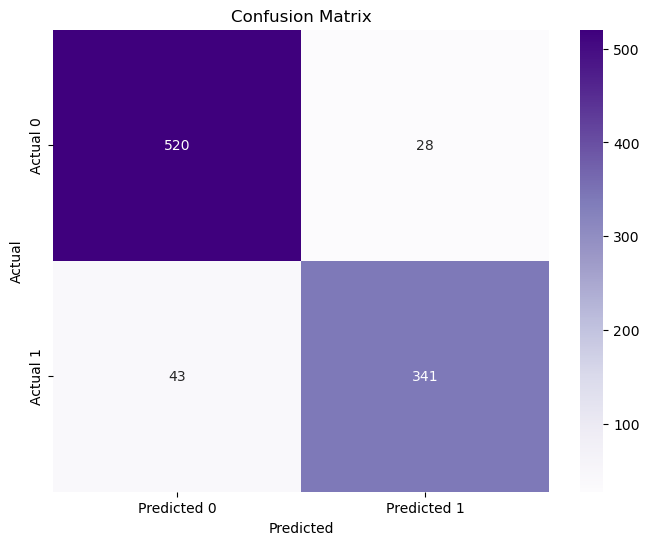

In [363]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats


"""missing_values = data.isna().sum()
print(missing_values)

z_scores = stats.zscore(data.select_dtypes(include=['float64', 'int64']))
outliers = (z_scores > 2) | (z_scores < -2)
outliers_count = outliers.sum(axis=0)
print(outliers_count)"""

print(f"Mean of N02: {data['NO2(GT)'].mean()}")


X = data[['CO(GT)', 'NOx(GT)', 'T', 'RH', 'AH', 'Month']]
y = (data['NO2(GT)'] > 110).astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
print(cm)

print("Size of train data:", X_train.shape)
print("Size of test data:", X_test.shape)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Purples', xticklabels=['Predicted 0', 'Predicted 1'], 
                                                     yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

